# Introduction

## The skyrmion

In [63]:
import numpy as np
import matplotlib.pyplot as plt

def skyrmion_ansatz(b, nx, ny):
    """
    generates a config with Q=1 via a stereographic projection of id: S^2 -> S^2;
    b is the size of the 'skyrmion'
    """
    X, Y = np.zeros((nx,ny)), np.zeros((nx,ny))
    for i in range(nx):
        for j in range(ny):
            X[i,j] = i
            Y[i,j] = j
        #end
    #end

    #shift the centre
    X -= (nx-1)//2+0.5
    Y -= (ny-1)//2+0.5
    #rescale
    X *= 1/b; Y *= 1/b
    #compute the projection
    n = np.zeros((3, nx, ny))
    n[0,:,:] = 2*X/(1+X**2+Y**2)
    n[1,:,:] = 2*Y/(1+X**2+Y**2)
    n[2,:,:] = (X**2+Y**2-1)/(X**2+Y**2+1)
    return n
#end

def ferromagnetic(nx,ny):
    n = np.zeros((3,nx,ny))
    n[2,:,:] = 1.0
    return n
#end

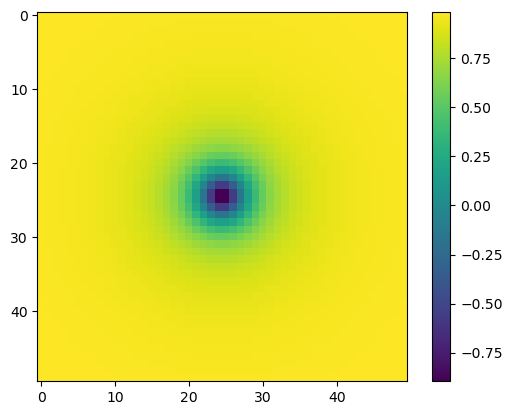

In [65]:
n = skyrmion_ansatz(3.0, 50,50)
plt.imshow(n[2,:,:])
plt.colorbar()

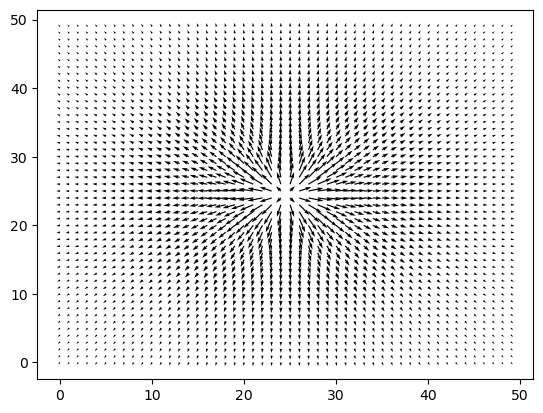

In [3]:
plt.quiver(n[1,:,:], n[0,:,:])

In [79]:
def H_vect(n,J1,J2,J3,B):
    E = 0
    nx = n.shape[1]; ny = n.shape[2]
    for i in range(nx):
        for j in range(ny):
            n_a = n[:,i,j]
            E -= B*n_a[2]
            for (k,l) in [(i+1,j),(i,j+1)]:
                k = k%nx; l = j%ny; # periodic BCs
                n_b = n[:,k,l]
                E -= J1*( n_a[0]*n_b[0]+n_a[1]*n_b[1]+n_a[2]*n_b[2] )
            for (k,l) in [(i+1,j+1),(i+1,j-1)]:
                k = k%nx; l = j%ny; # periodic BCs
                n_b = n[:,k,l]
                E -= J2*( n_a[0]*n_b[0]+n_a[1]*n_b[1]+n_a[2]*n_b[2] )
            for (k,l) in [(i+2,j),(i,j+2)]:
                k = k%nx; l = j%ny; # periodic BCs
                n_b = n[:,k,l]
                E -= J3*( n_a[0]*n_b[0]+n_a[1]*n_b[1]+n_a[2]*n_b[2] )
        #end
    #end
    E += nx*ny*(B+2*J1+2*J2+2*J3) #subtract the FM energy
    return E
#end
n = ferromagnetic(50,37)
H_vect(n,1.0, -0.2, -0.1, 1.23)

-2.2464519133791327e-10

Text(0, 0.5, '$E-E_{FM}$')

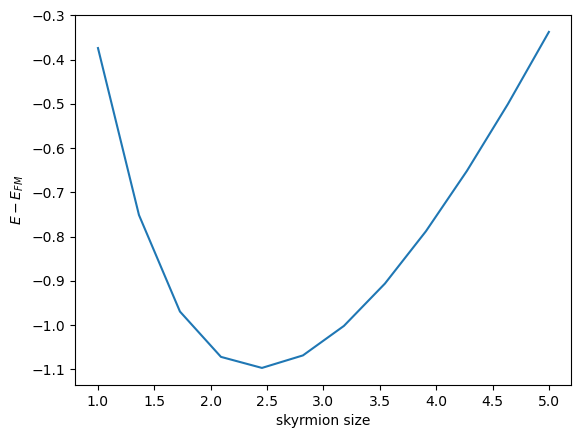

In [134]:
#J1 = 1.0; J2 = -0.25; J3 = -0.10; B = -0.006
J1 = 1.0; J2 = -0.25; J3 = -0.20; B = 0.0
nx = 30; ny =30

b_vals = np.linspace(1.0,5,12)
H_vals = []
for b in b_vals:
    n = skyrmion_ansatz(b, nx, ny)
    E = H_vect(n,J1,J2,J3,B)
    H_vals.append(E)
#end

plt.plot(b_vals,H_vals)
plt.xlabel("skyrmion size"); plt.ylabel("$E-E_{FM}$")

## Relaxation dynamics

To minimize the energy, we would like to perform gradient descent on $n$ :
$$
\dot{n} = - \nabla_n H
$$
But this would be unphysical as we need to ensure $|n|=1$. To fix the issue, we simply subtract from the RHS the part proportional to $n$, obtaining
$$
\dot{n} = -\nabla_n H + (n \cdot \nabla_n H) \; n
$$
so that $n \dot{n} = 0$.


In [150]:
def relax(n_init, nx, ny, J1, J2, J3, B, dt, N_steps):
    """
    RK4 for dn/dt = F(n)
    """
    def F(n,nx,ny,J1,J2,J3,B):
        g = np.zeros_like(n) # MINUS the gradient of H
        for i in range(nx):
            for j in range(ny):
                #external field
                g[2,i,j] += B
                for (k,l) in [(i+1,j),(i,j+1)]:
                    k = k%nx; l = j%ny; # periodic BCs
                    g[:,i,j] += J1* n[:,k,l]
                    g[:,k,l] += J1* n[:,i,j]

                for (k,l) in [(i+1,j+1),(i+1,j-1)]:
                    k = k%nx; l = j%ny; # periodic BCs
                    g[:,i,j] += J2* n[:,k,l]
                    g[:,k,l] += J2* n[:,i,j]

                for (k,l) in [(i+2,j),(i,j+2)]:
                    k = k%nx; l = j%ny; # periodic BCs
                    g[:,i,j] += J3* n[:,k,l]
                    g[:,k,l] += J3* n[:,i,j]
            #end
        #end

        #randomize ---> stochastic gradient descent
        #maxg = np.max(np.abs(g))
        #g += 0.05*maxg*np.random.normal(size = g.shape)

        for i in range(nx):
            for j in range(ny):
                gn = n[0,i,j]*g[0,i,j] + n[1,i,j]*g[1,i,j] + n[2,i,j]*g[2,i,j]
                g[:,i,j] = g[:,i,j] - gn*n[:,i,j]
        return g
    #endfunction


    n_arr = np.zeros((N_steps, 3, nx, ny))
    n = np.zeros_like(n_init)
    n = n_init
    for i in range(N_steps):
        n_arr[i,:,:,:] = n
        k1 = F(n, nx, ny, J1, J2, J3, B)
        #adaptive time step
        #maxf = np.max(np.abs(k1))
        #dt = 5E-2/ maxf
        #print("dt = ", dt)
        n += k1*dt
    return n_arr
        
    
#end
n_init = skyrmion_ansatz(2.5,nx,ny)
n_arr = relax(n_init, nx, ny, J1, J2, J3, B, dt=0.05,N_steps=50)

Text(0, 0.5, 'energy')

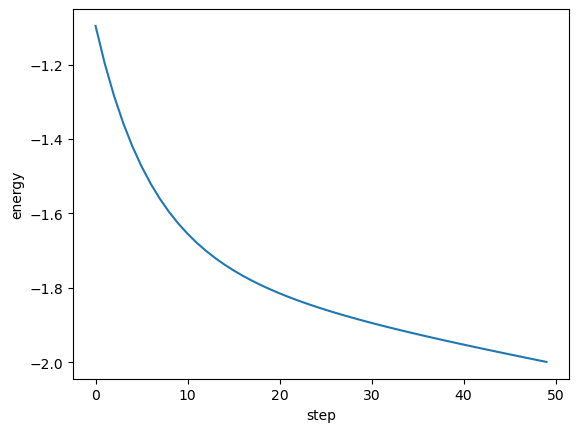

In [151]:
H_vals = [H_vect(n_arr[i,:,:,:],J1,J2,J3,B) for i in range(n_arr.shape[0])]
plt.plot(H_vals)
plt.xlabel("step"); plt.ylabel("energy")

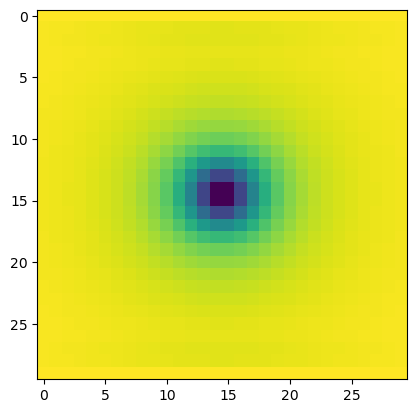

In [154]:
n_Sk = n_arr[-1,:,:,:]
plt.imshow(n_Sk[2,:,:])

In [156]:
def check_norm(n):
    norm = n[0,:,:]**2 + n[1,:,:]**2 + n[2,:,:]**2
    print("norm varies from", np.min(norm), "to", np.max(norm))
check_norm(n_Sk)

norm varies from 1.0000000060335021 to 1.0000104034224138


## Sterographic projection and the Hamiltonian

$$
n_x = \frac{w + \bar{w}}{1+\bar{w}w} \qquad n_y = -i \frac{w - \bar{w}}{1+\bar{w}w} \qquad n_z = \frac{1-\bar{w}w}{1+\bar{w}w} 
$$

The inverse mapping is

$$
|w|^2 = \frac{1-n_z}{1+n_z} \qquad w = \frac{n_x + i n_y}{1+n_z}
$$

In [159]:
def w_project(n):
    w = np.zeros((n.shape[1], n.shape[2]),dtype=complex)
    w = (n[0,:,:]+ 1j*n[1,:,:]) / (1+n[2,:,:])
    return w
#end

def n_vector(w):
    n = np.zeros((3, w.shape[0], w.shape[1]))
    n[0,:,:] = np.real( (w + np.conj(w)) / (1 + np.conj(w)*w) )
    n[1,:,:] = np.real(-1j * (w - np.conj(w)) / (1 + np.conj(w)*w))
    n[2,:,:] = np.real((1-w*np.conj(w)) / (1 + np.conj(w)*w))
    return n
#end

In [162]:
w0 = w_project(n_arr[-1,:,:,:])

In [163]:
def w(w0, lbd):
    return np.real(w0) + 1j*lbd*np.imag(w0)

def n_lbd(w0, lbd):
    return n_vector(w(w0,lbd))

In [164]:
def check_norm(n):
    norm = n[0,:,:]**2 + n[1,:,:]**2 + n[2,:,:]**2
    print("norm varies from", np.min(norm), "to", np.max(norm))

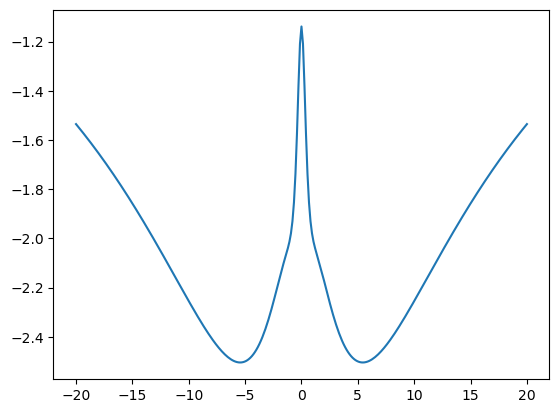

In [166]:
w0 = w_project(n_Sk)
lbd_vals = np.linspace(-20.0, 20.0, 301)
H_vals = []
for lbd in lbd_vals:
    n = n_vector(w(w0,lbd))
    #check_norm(n)
    H_vals.append(H_vect(n,J1,J2,J3,B))
plt.plot(lbd_vals,H_vals)


I need to
1. Test my H function
2. Make sure gradient-descent works well
3. Visualize and understand the configurations.
4. Scrutinize the choice of parameters (consider adding anisotropy, too!)